# Association Rule Mining of Solar Photovoltaic Power Generation

**Week 4 - Apriori Assignment**  

Github [Code: week4-apriori-assignment](https://github.com/tienhanprab/PhD_SUT_ENG552209_BigDataAnalytics/tree/main/week4-apriori-solar)

Dataset: [Solar Power Generation Data (Kaggle)](https://www.kaggle.com/datasets/anikannal/solar-power-generation-data)

Notebook นี้สร้าง transaction จากสภาวะแวดล้อมและระดับกำลังไฟฟ้าของระบบ
photovoltaic แล้วใช้ **Apriori** ค้นหา association rule รูปแบบ
$X \rightarrow Y$ จากข้อมูลจริง โดยไม่กำหนดผลล่วงหน้า

## tl;dr

- ข้อมูลต้นทาง 4 ไฟล์ครอบคลุมโรงไฟฟ้า 2 แห่ง 34 วัน หลัง aggregate
  inverter และ exact join กับ weather ได้ **6,416 plant-time rows**.
- ใช้เฉพาะช่วง `IRRADIATION > 0` และ coverage ของ inverter อย่างน้อย 50%
  เหลือ **3,607 daylight transactions**; แบ่งตามวันเป็น discovery
  2,527 transactions (24 วัน) และ validation 1,080 transactions (10 วัน).
- ตัวแปร continuous ถูกแบ่ง Low/Medium/High ด้วย tertile ที่ fit แยกตาม plant
  จาก discovery period เท่านั้น แล้วนำ boundary เดิมไปใช้กับ validation.
- Grid search เลือก `min_support=0.075` และ `min_confidence=0.60`;
  หลังกรองความน่าเชื่อถือและกฎซ้ำซ้อน เหลือ **Top 10 rules**.
- กฎพื้นฐานที่ชัดเจนคือ `Irradiation_Low -> ACPower_Low`:
  support **33.60%**, confidence **96.11%**, lift **2.77** จากทั้งหมด
  และยังคงทิศทางเดียวกันใน validation (confidence 94.02%, lift 2.48).
- ผลทั้งหมดเป็น **ความสัมพันธ์ร่วม ณ เวลาเดียวกัน ไม่ใช่เหตุและผล**;
  ระดับ Low/Medium/High เป็นระดับสัมพัทธ์ภายในแต่ละ plant.

## Context & Methods

**Research question:** What environmental conditions are associated with
low, medium, and high photovoltaic AC power generation?

### Key assumptions

1. หน่วย transaction คือ `(PLANT_ID, DATE_TIME)` ที่ช่วงเวลา 15 นาที ไม่ใช่
   inverter row เพราะ weather sensor อยู่ที่ plant grain.
2. ใช้ `AC_POWER_MEAN` ต่อ inverter ที่มี record ใน timestamp นั้น แทนผลรวม
   เพื่อไม่ให้จำนวน inverter rows ที่ขาดหายลดกำลังรวมโดยกลไกของข้อมูล.
3. วิเคราะห์ daylight เท่านั้นเพื่อไม่ให้กฎกลางคืนแบบ
   `Irradiation_Zero -> ACPower_Zero` ครองผลลัพธ์.
4. แบ่ง discovery/validation ด้วยทั้งวันตามลำดับเวลา ไม่ random split
   15-minute rows ที่มี autocorrelation.
5. Fit tertile แยก plant บน discovery dates; `High` หมายถึง top tertile
   เชิงสัมพัทธ์ ไม่ใช่ rated-capacity performance.
6. กฎหลักมี consequent เป็น `ACPower_*` เพียงหนึ่ง item และ antecedent
   เป็น environmental items 1-2 รายการเท่านั้น.

`DC_POWER`, `DAILY_YIELD`, `TOTAL_YIELD`, plant ID และ timestamp ไม่ถูกใช้เป็น
rule item: DC/AC เชื่อมกันโดย inverter จนเป็นกฎเชิง tautology ส่วน yield
เป็น cumulative/time proxy. ไม่สร้างตัวแปร "efficiency" เพราะ dataset ไม่มี
capacity, panel area และหน่วย irradiation ที่ยืนยันได้เพียงพอ.

## Requirement 1: Select a Kaggle dataset

เลือก [Solar Power Generation Data](https://www.kaggle.com/datasets/anikannal/solar-power-generation-data)
version 1 ซึ่งมี generation data ระดับ inverter และ weather data ระดับ plant
สำหรับโรงไฟฟ้า 2 แห่งในอินเดียช่วง 15 May-17 June 2020.

ไฟล์ต้นทางถูก pin ด้วยขนาดและ SHA-256; notebook ตรวจครบทั้ง 4 ไฟล์ก่อนวิเคราะห์.

## Data

### 1. Set up a reproducible environment

In [1]:
from __future__ import annotations

import json
import platform
from importlib.metadata import version
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import mlxtend
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from solar_apriori.analysis import (
    add_transactions,
    apply_tertile_edges,
    encode_transactions,
    enrich_rule_metrics,
    fit_tertile_edges,
    make_top_rules_table,
    mine_apriori_rules,
    plot_rule_network,
    plot_tuning_heatmap,
    prepare_plant_time_data,
    prune_redundant_rules,
    screen_stable_rules,
    select_daylight_population,
    split_dates,
    transaction_lists,
    tune_thresholds,
)
from solar_apriori.download import (
    DATASET_HANDLE,
    METADATA_FILENAME,
    validate_dataset,
)


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "config.json").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the Week 4 project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
for directory in (PROCESSED_DIR, FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

config = json.loads((PROJECT_ROOT / "config.json").read_text(encoding="utf-8"))
analysis_config = config["analysis"]

sns.set_theme(context="notebook", style="whitegrid", font_scale=1.0)
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 200,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#262626",
        "text.color": "#262626",
        "grid.color": "#D9D9D6",
        "grid.linewidth": 0.6,
    }
)

environment = pd.DataFrame(
    {
        "Component": [
            "Python", "pandas", "NumPy", "mlxtend",
            "NetworkX", "Matplotlib",
        ],
        "Version": [
            platform.python_version(), pd.__version__, np.__version__,
            mlxtend.__version__, nx.__version__, mpl.__version__,
        ],
    }
)
display(environment)

,Component,Version
0,Python,3.12.14
1,pandas,3.0.6
2,NumPy,2.5.3
3,mlxtend,0.25.0
4,NetworkX,3.7
5,Matplotlib,3.11.2


### 2. Validate all four source files and provenance

In [2]:
validated_files = validate_dataset(RAW_DIR)
metadata = json.loads((RAW_DIR / METADATA_FILENAME).read_text(encoding="utf-8"))
assert metadata["dataset_handle"] == DATASET_HANDLE

integrity_table = pd.DataFrame(
    [
        {
            "File": filename,
            "Size (MiB)": observed.size_bytes / 1024**2,
            "SHA-256": observed.sha256,
        }
        for filename, observed in validated_files.items()
    ]
)
display(integrity_table.round({"Size (MiB)": 2}))

,File,Size (MiB),SHA-256
0,Plant_1_Generation_Data.csv,4.61,882f75f1c295946633617646cc92343ddb6fb821a2546c...
1,Plant_1_Weather_Sensor_Data.csv,0.27,91325041328745c288cb809aebd8b1b59cde5428450090...
2,Plant_2_Generation_Data.csv,5.54,9b735e9278774d4d1dd4601047315ef50b3793244d8924...
3,Plant_2_Weather_Sensor_Data.csv,0.29,cafd80885a51b88521b3301cffa4e4f013e2516fcb3478...


### 3. Audit source grain, aggregate generation, and exact-join weather

Generation key ที่คาดหวังคือ `(PLANT_ID, DATE_TIME, SOURCE_KEY)`;
weather key คือ `(PLANT_ID, DATE_TIME)`. Generation ถูก aggregate ก่อน join
เพื่อไม่ให้ weather หนึ่งแถวถูกทำซ้ำ 22 ครั้ง.

In [3]:
prepared = prepare_plant_time_data(RAW_DIR)
display(Markdown("**Source quality**"))
display(prepared.source_quality)
display(Markdown("**Exact timestamp join**"))
display(prepared.merge_quality)
display(Markdown("**Inverter-row coverage**"))
display(prepared.inverter_coverage)

prepared.source_quality.to_csv(TABLE_DIR / "source_quality.csv", index=False)
prepared.merge_quality.to_csv(TABLE_DIR / "merge_quality.csv", index=False)
prepared.inverter_coverage.to_csv(
    TABLE_DIR / "inverter_coverage.csv", index=False
)

assert prepared.source_quality["Null values"].sum() == 0
assert prepared.source_quality["Exact duplicate rows"].sum() == 0
assert prepared.source_quality["Duplicate grain keys"].sum() == 0
assert prepared.merge_quality["Matched timestamps"].sum() == 6_416

**Source quality**

,Plant,Source,Rows,Columns,Null values,Exact duplicate rows,Duplicate grain keys
0,1,generation,68778,7,0,0,0
1,1,weather,3182,6,0,0,0
2,2,generation,67698,7,0,0,0
3,2,weather,3259,6,0,0,0


**Exact timestamp join**

,Plant,Generation timestamps,Weather timestamps,Matched timestamps,Generation only,Weather only
0,1,3158,3182,3157,1,25
1,2,3259,3259,3259,0,0


**Inverter-row coverage**

,Plant,Expected inverters,Complete timestamps,Incomplete timestamps,Minimum observed inverters,Coverage distribution
0,1,22,3057,100,4,"{4.0: 1, 10.0: 32, 14.0: 23, 16.0: 1, 18.0: 14..."
1,2,22,2355,904,12,"{12: 64, 18: 840, 22: 2355}"


Plant 1 มี generation-only 1 timestamp และ weather-only 25 timestamps;
Plant 2 exact-match ครบทุก timestamp. บางช่วงมี inverter records ไม่ครบ 22 ตัว
จึงใช้ค่า power เฉลี่ยของ records ที่สังเกตได้ และตัดช่วงที่ coverage ต่ำกว่า 50%.

### 4. Select daylight intervals and split by complete dates

In [4]:
daylight, population_audit = select_daylight_population(
    prepared.plant_time,
    minimum_irradiation=analysis_config["daylight_min_irradiation"],
    minimum_inverter_coverage=analysis_config["minimum_inverter_coverage"],
)
discovery_raw, validation_raw, split_summary = split_dates(
    daylight, analysis_config["discovery_day_fraction"]
)
display(population_audit)
display(split_summary)
population_audit.to_csv(TABLE_DIR / "population_audit.csv", index=False)
split_summary.to_csv(TABLE_DIR / "temporal_split.csv", index=False)

assert len(daylight) == 3_607
assert len(discovery_raw) == 2_527
assert len(validation_raw) == 1_080
assert discovery_raw["DATE"].max() < validation_raw["DATE"].min()

,Population step,Rows
0,Exact generation-weather matches,6416
1,Complete analytical fields,6416
2,Daylight (IRRADIATION > 0),3616
3,Inverter coverage >= 50%,3607
4,Final plant-time transactions,3607


,Split,First date,Last date,Distinct dates,Transactions
0,Discovery,2020-05-15,2020-06-07,24,2527
1,Validation,2020-06-08,2020-06-17,10,1080


## Requirement 2: Prepare data as transaction lists

### 5. Fit Low/Medium/High boundaries without validation leakage

Tertile boundaries ถูก fit แยก plant จาก discovery dates แล้ว freeze ไว้.
วิธีนี้หลีกเลี่ยง raw-scale artefact ระหว่าง plant และทำให้ validation เป็นข้อมูล
ที่ไม่ได้กำหนด boundary.

In [5]:
bin_edges = fit_tertile_edges(discovery_raw)
binned = add_transactions(apply_tertile_edges(daylight, bin_edges))
discovery_dates = set(discovery_raw["DATE"])
discovery = binned.loc[binned["DATE"].isin(discovery_dates)].copy()
validation = binned.loc[~binned["DATE"].isin(discovery_dates)].copy()

bin_edges.to_csv(TABLE_DIR / "bin_edges.csv", index=False)
display(bin_edges.round(4))

,Plant,Source column,Item family,Low/Medium boundary,Medium/High boundary
0,1,IRRADIATION,Irradiation,0.2425,0.5805
1,1,AMBIENT_TEMPERATURE,AmbientTemp,26.4640,29.6032
2,1,MODULE_TEMPERATURE,ModuleTemp,33.1401,47.0439
3,1,AC_POWER_MEAN,ACPower,332.6404,788.0426
4,2,IRRADIATION,Irradiation,0.2094,0.6636
5,2,AMBIENT_TEMPERATURE,AmbientTemp,28.4708,33.3483
6,2,MODULE_TEMPERATURE,ModuleTemp,33.8377,48.7694
7,2,AC_POWER_MEAN,ACPower,264.2377,658.7921


### 6. Inspect the transaction lists

In [6]:
transaction_export = binned[
    ["PLANT_NUMBER", "TIMESTAMP", "DATE", "TRANSACTION"]
].copy()
transaction_export["Split"] = np.where(
    transaction_export["DATE"].isin(discovery_dates),
    "Discovery",
    "Validation",
)
transaction_export["Items"] = transaction_export["TRANSACTION"].map(
    lambda values: " | ".join(sorted(values))
)
transaction_export.drop(columns="TRANSACTION").to_csv(
    PROCESSED_DIR / "transactions.csv", index=False
)

transaction_preview = transaction_export[
    ["PLANT_NUMBER", "TIMESTAMP", "Split", "Items"]
].sample(8, random_state=analysis_config["random_state"])
display(transaction_preview.sort_values("TIMESTAMP"))

encoded_discovery = encode_transactions(discovery)
display(encoded_discovery.head(8).astype(int))
display(
    encoded_discovery.mean()
    .sort_values(ascending=False)
    .rename("Discovery item support")
    .to_frame()
    .round(4)
)

assert all(len(items) == 4 for items in transaction_lists(binned))
assert encoded_discovery.sum(axis=1).eq(4).all()

,PLANT_NUMBER,TIMESTAMP,Split,Items
170,2.0,2020-05-16 13:30:00,Discovery,ACPower_High | AmbientTemp_High | Irradiation_...
1023,2.0,2020-05-24 16:00:00,Discovery,ACPower_Medium | AmbientTemp_High | Irradiatio...
1583,1.0,2020-05-30 07:30:00,Discovery,ACPower_Low | AmbientTemp_Low | Irradiation_Lo...
2031,1.0,2020-06-03 10:00:00,Discovery,ACPower_Medium | AmbientTemp_Low | Irradiation...
2194,2.0,2020-06-04 17:15:00,Discovery,ACPower_Low | AmbientTemp_Low | Irradiation_Lo...
3030,2.0,2020-06-12 13:45:00,Validation,ACPower_Medium | AmbientTemp_Low | Irradiation...
3144,2.0,2020-06-13 14:45:00,Validation,ACPower_Medium | AmbientTemp_Medium | Irradiat...
3564,2.0,2020-06-17 13:30:00,Validation,ACPower_Medium | AmbientTemp_Low | Irradiation...


,ACPower_High,ACPower_Low,ACPower_Medium,AmbientTemp_High,AmbientTemp_Low,AmbientTemp_Medium,Irradiation_High,Irradiation_Low,Irradiation_Medium,ModuleTemp_High,ModuleTemp_Low,ModuleTemp_Medium
0,0,1,0,0,1,0,0,1,0,0,1,0
1,0,1,0,0,1,0,0,1,0,0,1,0
2,0,1,0,0,1,0,0,1,0,0,1,0
3,0,1,0,0,1,0,0,1,0,0,1,0
4,0,1,0,0,1,0,0,1,0,0,1,0
5,0,1,0,0,1,0,0,1,0,0,1,0
6,0,1,0,0,1,0,0,1,0,0,1,0
7,0,1,0,0,1,0,0,1,0,0,1,0


,Discovery item support
ACPower_Low,0.3336
AmbientTemp_Low,0.3336
Irradiation_Low,0.3336
ModuleTemp_Low,0.3336
ACPower_High,0.3332
ACPower_Medium,0.3332
AmbientTemp_High,0.3332
AmbientTemp_Medium,0.3332
Irradiation_High,0.3332
Irradiation_Medium,0.3332


หนึ่ง transaction มี exactly one item จากแต่ละ family:
`Irradiation_*`, `AmbientTemp_*`, `ModuleTemp_*`, `ACPower_*`.
Apriori จึงรับ categorical transaction จริง ไม่ใช่ค่า numeric ดิบ.

## Requirement 3: Perform Association Rule Mining using Apriori

### 7. Tune `min_support` and `min_confidence`

ทดลอง support 7 ค่าและ confidence 4 ค่า. ทุก setting ใช้ `max_len=3`
และนับเฉพาะ environmental $\rightarrow$ AC-power rules. กฎที่รายงานต้องมี
joint count อย่างน้อย 30, ครอบคลุมอย่างน้อย 5 discovery dates, discovery lift
> 1.1, validation lift > 1, validation antecedent count อย่างน้อย 30 และ lift
> 1 ในทั้งสอง plants. กฎยาวถูกตัดเมื่อแทบไม่เพิ่ม confidence/lift จากกฎ subset.

,min_support,min_confidence,frequent_itemsets,all_rules,target_rules,stable_rules,nonredundant_rules
0,0.020,0.5,98,123,29,26,13
1,0.020,0.6,98,111,27,25,13
2,0.020,0.7,98,82,24,22,11
3,0.020,0.8,98,59,19,17,9
4,0.030,0.5,94,123,29,26,13
5,0.030,0.6,94,111,27,25,13
6,0.030,0.7,94,82,24,22,11
7,0.030,0.8,94,59,19,17,9
8,0.050,0.5,75,102,25,24,12
9,0.050,0.6,75,96,24,23,12


**Selected:** `min_support=0.075` and `min_confidence=0.6` -> 19 stable rules and 10 nonredundant rules.

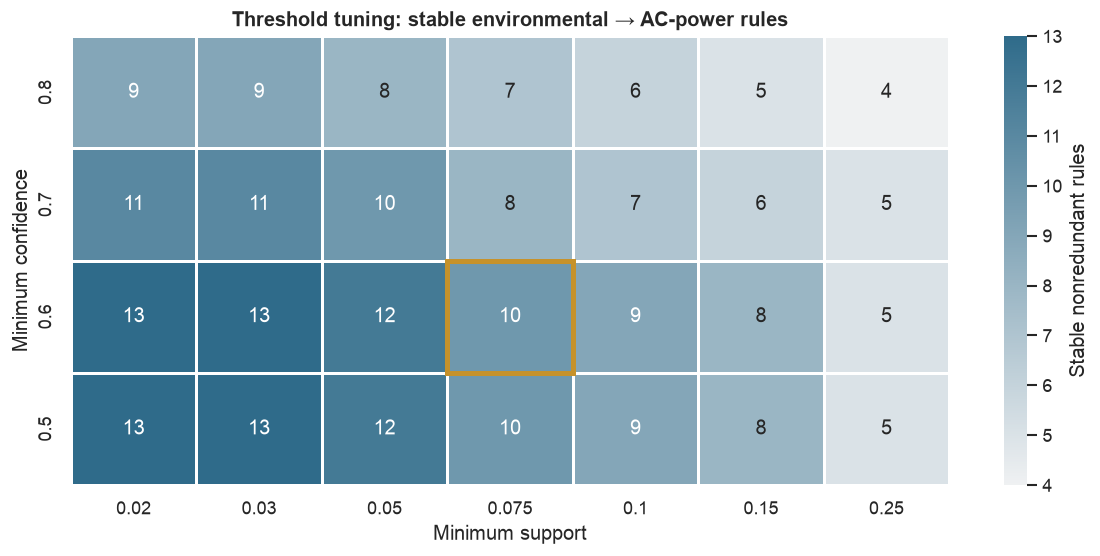

In [7]:
screening = {
    "minimum_joint_count": analysis_config["minimum_joint_count"],
    "minimum_discovery_days": analysis_config["minimum_discovery_days"],
    "minimum_discovery_lift": analysis_config["minimum_discovery_lift"],
    "minimum_validation_lift": analysis_config["minimum_validation_lift"],
    "minimum_validation_antecedent_count": analysis_config[
        "minimum_validation_antecedent_count"
    ],
    "minimum_plant_lift": analysis_config["minimum_plant_lift"],
}

tuning = tune_thresholds(
    discovery,
    validation,
    binned,
    support_grid=analysis_config["support_grid"],
    confidence_grid=analysis_config["confidence_grid"],
    max_length=analysis_config["max_itemset_length"],
    screening=screening,
    redundancy_confidence_gain=analysis_config[
        "redundancy_confidence_gain"
    ],
    redundancy_lift_gain=analysis_config["redundancy_lift_gain"],
)
tuning.to_csv(TABLE_DIR / "threshold_tuning.csv", index=False)
display(tuning)

selected_support = analysis_config["selected_min_support"]
selected_confidence = analysis_config["selected_min_confidence"]
selected_row = tuning.loc[
    tuning["min_support"].eq(selected_support)
    & tuning["min_confidence"].eq(selected_confidence)
]
display(Markdown(
    f"**Selected:** `min_support={selected_support}` and "
    f"`min_confidence={selected_confidence}` -> "
    f"{int(selected_row['stable_rules'].iloc[0])} stable rules and "
    f"{int(selected_row['nonredundant_rules'].iloc[0])} nonredundant rules."
))

plot_tuning_heatmap(
    tuning,
    selected_support=selected_support,
    selected_confidence=selected_confidence,
    output_path=FIGURE_DIR / "threshold_tuning_heatmap.png",
)
plt.show()

ค่า 0.075/0.60 เป็นจุดสมดุลที่ยังคงกฎซึ่งผ่าน validation และเหลือ 10
patterns หลังตัด redundancy. ค่าใน lecture เป็นตัวอย่าง ไม่ใช่ threshold บังคับ.

### 8. Mine and validate the selected Apriori rules

In [8]:
frequent_itemsets, all_rules, target_rules = mine_apriori_rules(
    encoded_discovery,
    minimum_support=selected_support,
    minimum_confidence=selected_confidence,
    max_length=analysis_config["max_itemset_length"],
)
enriched_rules = enrich_rule_metrics(
    target_rules, discovery, validation, binned
)
stable_rules = screen_stable_rules(
    enriched_rules,
    minimum_support=selected_support,
    minimum_confidence=selected_confidence,
    **screening,
)
nonredundant_rules = prune_redundant_rules(
    stable_rules,
    minimum_confidence_gain=analysis_config[
        "redundancy_confidence_gain"
    ],
    minimum_lift_gain=analysis_config["redundancy_lift_gain"],
)
top_rules = make_top_rules_table(
    nonredundant_rules, top_n=analysis_config["top_n"]
)

mining_summary = pd.DataFrame(
    {
        "Stage": [
            "Frequent itemsets", "All confidence-qualified rules",
            "Environmental -> AC-power rules", "Stable rules",
            "Nonredundant Top-N rules",
        ],
        "Count": [
            len(frequent_itemsets), len(all_rules), len(target_rules),
            len(stable_rules), len(top_rules),
        ],
    }
)
display(mining_summary)
assert len(top_rules) == 10

,Stage,Count
0,Frequent itemsets,58
1,All confidence-qualified rules,83
2,Environmental -> AC-power rules,19
3,Stable rules,19
4,Nonredundant Top-N rules,10


### 9. Independently verify support, confidence, and lift from counts

In [9]:
first_rule = top_rules.iloc[0]
computed_support = first_rule["n(X∪Y)"] / len(binned)
computed_confidence = first_rule["n(X∪Y)"] / first_rule["n(X)"]
computed_lift = computed_confidence / first_rule["Consequent baseline"]
formula_check = pd.DataFrame(
    {
        "Metric": ["Support", "Confidence", "Lift"],
        "Stored": [
            first_rule["Support"], first_rule["Confidence"],
            first_rule["Lift"],
        ],
        "Recomputed from counts": [
            computed_support, computed_confidence, computed_lift,
        ],
    }
)
display(formula_check.round(6))
assert np.allclose(
    formula_check["Stored"], formula_check["Recomputed from counts"]
)

,Metric,Stored,Recomputed from counts
0,Support,0.109787,0.109787
1,Confidence,0.874172,0.874172
2,Lift,2.969058,2.969058


- **Support** = $n(X \cup Y)/N$: สัดส่วน daylight plant-time transactions
  ที่มีทั้ง antecedent และ consequent.
- **Confidence** = $n(X \cup Y)/n(X)$: เมื่อพบ antecedent แล้ว พบ consequent
  กี่ส่วน.
- **Lift** = $confidence/support(Y)$: มากกว่าค่า baseline ของ consequent
  กี่เท่า; lift > 1 หมายถึงเกิดร่วมกันมากกว่าภายใต้ independence.

## Requirement 4: Top-N rules table and visualization

### 10. Top 10 rules

In [10]:
top_rules.to_csv(TABLE_DIR / "top_10_rules.csv", index=False)
display(
    top_rules.style.format(
        {
            "Support": "{:.2%}",
            "Confidence": "{:.2%}",
            "Consequent baseline": "{:.2%}",
            "Lift": "{:.2f}",
            "Validation support": "{:.2%}",
            "Validation confidence": "{:.2%}",
            "Validation lift": "{:.2f}",
            "Plant 1 lift": "{:.2f}",
            "Plant 2 lift": "{:.2f}",
        }
    )
)

,Rule ID,Antecedent,Consequent,n(X),n(X∪Y),Distinct days,Support,Confidence,Consequent baseline,Lift,Validation support,Validation confidence,Validation lift,Plant 1 lift,Plant 2 lift
0,R1,"AmbientTemp_High, Irradiation_High",ACPower_High,453,396,27,10.98%,87.42%,29.44%,2.97,4.17%,91.84%,4.51,3.09,2.77
1,R2,Irradiation_High,ACPower_High,1053,872,34,24.18%,82.81%,29.44%,2.81,15.65%,80.09%,3.93,3.07,2.47
2,R3,Irradiation_Low,ACPower_Low,1261,1212,34,33.60%,96.11%,34.74%,2.77,36.39%,94.02%,2.48,2.85,2.69
3,R4,ModuleTemp_High,ACPower_High,976,751,33,20.82%,76.95%,29.44%,2.61,9.44%,76.12%,3.74,2.69,2.51
4,R5,"AmbientTemp_Low, Irradiation_Medium",ACPower_Medium,498,437,34,12.12%,87.75%,35.82%,2.45,17.41%,88.68%,2.13,2.71,2.24
5,R6,ModuleTemp_Low,ACPower_Low,1325,1108,34,30.72%,83.62%,34.74%,2.41,35.09%,78.63%,2.07,2.58,2.26
6,R7,"Irradiation_Medium, ModuleTemp_Medium",ACPower_Medium,946,800,34,22.18%,84.57%,35.82%,2.36,27.41%,83.62%,2.01,2.78,1.99
7,R8,Irradiation_Medium,ACPower_Medium,1293,1073,34,29.75%,82.99%,35.82%,2.32,35.83%,85.81%,2.06,2.74,1.97
8,R9,ModuleTemp_Medium,ACPower_Medium,1306,860,34,23.84%,65.85%,35.82%,1.84,29.44%,68.53%,1.64,2.06,1.64
9,R10,AmbientTemp_Low,ACPower_Low,1412,864,34,23.95%,61.19%,34.74%,1.76,30.74%,58.35%,1.54,1.80,1.73


ตารางหลักใช้ metric จาก daylight transactions ทั้ง 3,607 แถวเพื่อให้ตีความง่าย;
validation columns ยังคงแสดง stability บน 10 วันช่วงท้าย. Rule order เรียงตาม
overall lift, confidence และ support หลังผ่าน discovery-only selection.

### 11. Directed rule-item network

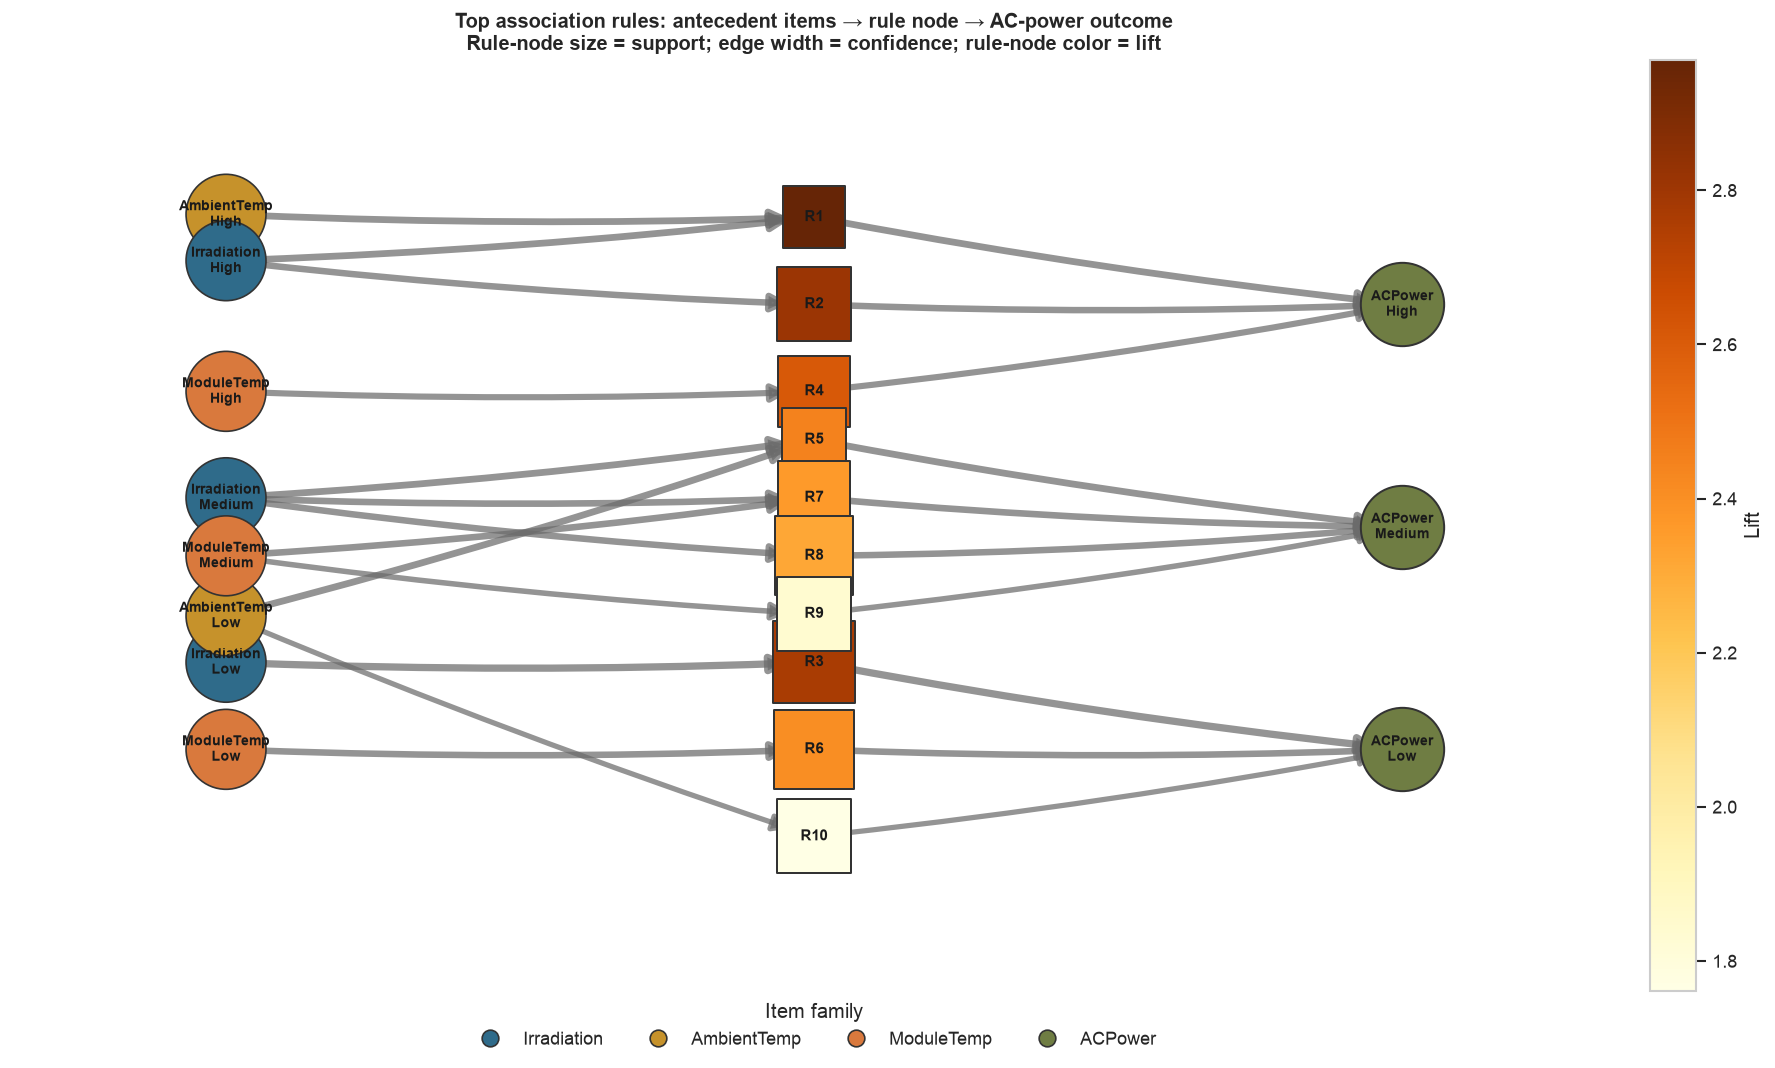

In [11]:
plot_rule_network(
    top_rules,
    output_path=FIGURE_DIR / "top_10_rule_network.png",
    random_state=analysis_config["random_state"],
)
plt.show()

Network ใช้ item -> rule node -> outcome เพื่อรักษาความหมายของ antecedent
หลายเงื่อนไข; การลากเส้น item-to-item โดยตรงจะทำให้ conjunction ผิดความหมาย.
ขนาด rule node แทน support, ความหนาเส้นแทน confidence และสี rule node แทน lift.

## Requirement 5: Interpret 3-5 key rules with context insights

### Key Rule 1 - High irradiation and high ambient temperature -> High AC power

**R1:** `{AmbientTemp_High, Irradiation_High} -> {ACPower_High}`  
Support = **10.98%**, Confidence = **87.42%**, Lift = **2.97**.

10.98% ของ daylight intervals ทั้งหมดมีสามสถานะนี้พร้อมกัน และเมื่อทั้ง ambient
temperature กับ irradiation อยู่ระดับสูง 87.42% ของช่วงนั้นมี AC power สูงด้วย.
โอกาสพบ high AC power สูงกว่าค่า baseline 2.97 เท่า. ใน validation เงื่อนไขนี้
เกิดน้อยลง (support 4.17%) แต่ confidence 91.84% และ lift 4.51 จึงยังคงทิศทาง.
นี่ไม่ได้พิสูจน์ว่า ambient heat เพิ่มกำลัง; high ambient temperature อาจเป็น proxy
ของช่วงแดดจัด.

### Key Rule 2 - High irradiation -> High AC power

**R2:** `{Irradiation_High} -> {ACPower_High}`  
Support = **24.18%**, Confidence = **82.81%**, Lift = **2.81**.

ประมาณหนึ่งในสี่ของ daylight intervals มีทั้ง high irradiation และ high AC power.
เมื่อ irradiation สูง 82.81% ของช่วงเวลามีกำลัง AC สูง ซึ่งเป็น physical sanity check
ที่คาดหมายได้. Validation confidence = 80.09% และ lift = 3.93 สนับสนุนว่า pattern
ไม่ได้เกิดเฉพาะช่วง discovery.

### Key Rule 3 - Low irradiation -> Low AC power

**R3:** `{Irradiation_Low} -> {ACPower_Low}`  
Support = **33.60%**, Confidence = **96.11%**, Lift = **2.77**.

33.60% ของ daylight intervals อยู่ใน joint state นี้ และในช่วงที่ irradiation ต่ำ
96.11% มีกำลัง AC ต่ำ. Validation confidence ยังสูง 94.02% (lift 2.48).
กฎนี้เหมาะเป็น baseline QA ของระบบและเป็นกฎที่เสถียรที่สุดกฎหนึ่ง แต่ไม่ใช่
maintenance alarm เพราะ low irradiation เป็นสภาวะแวดล้อมตามปกติ.

### Key Rule 4 - Medium irradiation with low ambient temperature -> Medium AC power

**R5:** `{AmbientTemp_Low, Irradiation_Medium} -> {ACPower_Medium}`  
Support = **12.12%**, Confidence = **87.75%**, Lift = **2.45**.

เมื่อสองเงื่อนไขนี้เกิดร่วมกัน 87.75% ของช่วงเวลามี medium AC power เทียบกับ
baseline medium-power 35.82%. Validation confidence = 88.68% และ lift = 2.13.
กฎนี้เพิ่มบริบทจาก irradiation อย่างเดียว แต่ ambient temperature ยังอาจสะท้อน
เวลาในวัน/สภาพอากาศ จึงควรใช้เป็น operating-context rule ไม่ใช่ causal control rule.

### Key Rule 5 - Medium irradiation and medium module temperature -> Medium AC power

**R7:** `{Irradiation_Medium, ModuleTemp_Medium} -> {ACPower_Medium}`  
Support = **22.18%**, Confidence = **84.57%**, Lift = **2.36**.

กฎนี้เกิดใน 22.18% ของ daylight intervals และมี confidence 84.57%; validation
confidence = 83.62% และ lift = 2.01. เป็น operating regime ที่พบข้ามทั้ง 34 วัน.
อย่างไรก็ตาม module temperature ถูกขับบางส่วนโดย irradiation เอง จึงไม่ควร
ตีความเป็นหลักฐานตรงของ thermal derating.

## Takeaways

1. Assignment requirements ครบ: Kaggle dataset, transaction lists, Apriori,
   threshold tuning, support/confidence, Top-10 table, network graph และ 5 insights.
2. Irradiation level เป็นตัวแปรที่สัมพันธ์กับ AC-power level ชัดที่สุดและเสถียร
   ทั้งช่วงเวลาและทั้งสอง plants.
3. Temperature interaction rules ให้บริบทเพิ่มเติม แต่ไม่ใช่หลักฐานเชิงสาเหตุ;
   การสรุป thermal efficiency ต้องมี capacity/area/unit metadata เพิ่มเติม.
4. ผลนี้อธิบาย co-occurrence ณ 15-minute interval ไม่ใช่ forecast. หากต้องการ
   predictive maintenance ควรสร้าง lagged transactions หรือ anomaly labels แยกงาน.

**Scope caveat:** support เป็นสัดส่วนของ daylight plant-time intervals ที่เลือก
ไม่ใช่สัดส่วนพลังงาน, จำนวนวัน หรือ independent trials. การใช้ tertile ทำให้
Low/Medium/High เป็นคำเปรียบเทียบภายในข้อมูลชุดนี้เท่านั้น.

## Reproducibility outputs

- `data/processed/transactions.csv` - transaction list พร้อม plant/timestamp/split
- `outputs/tables/bin_edges.csv` - frozen tertile boundaries
- `outputs/tables/threshold_tuning.csv` - support-confidence grid
- `outputs/tables/top_10_rules.csv` - final rule table
- `outputs/figures/threshold_tuning_heatmap.png` - tuning visualization
- `outputs/figures/top_10_rule_network.png` - rule network